# Task 1: Data Selection & Handling
It is our initial opinion that station choice is essentially arbitruary, provided we corectly pick 2 stations from each category. The data consists of 12 air quality monitoring stations in Beijing, 8 of which are classified as _Urban_ with the remainder classified as _Suburban_ (Xu et al., 2020). However to justify our choice, lets demonstrate the power of statistics, without jumping the gun of the full analysis in section 2.1. Lower levels of annual average PM2.5 concentrations were reported for the 4 suburban districts: Changpingzhen, Dingling, Huairouzhen, and Shunyixincheng (Batterman et al., 2016).

These lower annual averages concentrations should therefore be reflected in the first moment of the distributions:

In [84]:
!pip install seaborn holidays statsmodels jinja2 streamlit streamlit-option-menu

In [85]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import holidays
import sys
import streamlit as st

We have an existing devlopment environment for Jupyter notebooks running on personal machines, but the solution has to work in CoLab, the logic below clones our repo and switches to the correct location when running from CoLab, however it does require secrets to be configured: 

In [86]:
if 'google.colab' in sys.modules:
    print("Running in Google Colab")

    from google.colab import userdata

    user = userdata.get('username')
    email = userdata.get('email')

    ! git config --global user.name {user}
    ! git config --global user.email {email}

    repo = userdata.get('repo')
    token = userdata.get('token')
    ! git clone https://{token}@github.com/{user}/{repo}.git

    %cd {repo}

else:
    print("Not running in Google Colab")

Not running in Google Colab


We need to adjust output settings to be able to see enough useful information:

In [87]:
pd.set_option('display.width', 120)

Only some of the dataset relates to pollution components, the remained are time and weather related:

In [88]:
pollution_components = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
meteorological_components = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

So far the literature provided in the assignment brief seems to lean toward the PM2.5 component, so lets try something with the averages:

In [89]:
def get_sample_average(dataset: Path):
    df = pd.read_csv(dataset)
    return (df['PM2.5'].mean(), df['station'][0])

sample_averages = list()
[sample_averages.append(get_sample_average(dataset)) for dataset in Path('./AssessmentData').iterdir()]
sample_averages.sort()

for avg in sample_averages:
    print(f'Sample average(PM2.5): {avg[0]:.2f} for {avg[1]} station.')

Sample average(PM2.5): 65.99 for Dingling station.
Sample average(PM2.5): 69.63 for Huairou station.
Sample average(PM2.5): 71.10 for Changping station.
Sample average(PM2.5): 79.49 for Shunyi station.
Sample average(PM2.5): 82.16 for Tiantan station.
Sample average(PM2.5): 82.77 for Aotizhongxin station.
Sample average(PM2.5): 82.93 for Guanyuan station.
Sample average(PM2.5): 83.37 for Wanliu station.
Sample average(PM2.5): 83.85 for Gucheng station.
Sample average(PM2.5): 84.84 for Nongzhanguan station.
Sample average(PM2.5): 85.02 for Wanshouxigong station.
Sample average(PM2.5): 86.19 for Dongsi station.


Exactly as expected, the urban areas all show higher average values for PM2.5 the suburban areas. Even the ordering matches, B1-B4, outlined in Batterman et al. (2016). An interesting observation, given Batterman's dates only partially cover the data we have.  

Continuing with Batterman's classifications we decided on a station in each zone, Z1-Z4, for the maximum potential contrast in pollution concentrations:

| Station | Abbreviation | Batterman Zone | Reason Chosen |
| ------- | ------------- | -------------- | ------------- |
| Huairou | HR | Z1 | The only station in the ecological conservation zone |
| Shunyixincheng | SY | Z2 | a new urban development bordering Z1 |
| Nongzhanguan | NZG | Z3 | An urban functioning expanding bordering Z2 |
| Dongsi | DS | Z4 | A capital function core bordering Z3 |

As part of the task we need to combine those datasets into a single dataset, firstly, load the chosen datasets:

In [90]:
station_data = list()
for dataset in Path('./AssessmentData').iterdir():
    if any(name in dataset.name for name in ['Huairou', 'Shunyi', 'Nongzhanguan', 'Dongsi']):
        station_data.append(pd.read_csv(dataset))

Then we need to merge them:

In [91]:
time_cols = ['year', 'month', 'day', 'hour']

station_data = pd.concat(station_data, ignore_index=True)

Then, ensure proper handling of timestamps:

In [92]:
station_data['datetime'] = pd.to_datetime(station_data[time_cols])
station_data = station_data.drop(time_cols, axis=1)
station_data = station_data.set_index('datetime')

Finally, ensure proper handling of station identifiers - It is a little early for one-hot encoding the stations, they are however _categorical_ data and while in our opinion the pandas approach _smells_, it looks to be the documented way to do it (McKinney, 2022, section 7.5):

In [93]:
station_data['station'] = station_data['station'].astype('category')
station_data['station'].dtypes

CategoricalDtype(categories=['Dongsi', 'Huairou', 'Nongzhanguan', 'Shunyi'], ordered=False, categories_dtype=object)

# Task 2: Exploratory Data Analysis


What does the data actually look like, for that we check the shape:

In [94]:
station_data.shape

(140256, 14)

Fourteen columns, which are defined as:

In [95]:
station_data.columns

Index(['No', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'], dtype='object')

# TODO: Find the actual definitions - Know what they are but want correct units, etc

Of course, we originally had more columns, but dropped those date/time columns in favour of the datetime index above.

The datatypes mostly make sense, but clearly there is missing data which we need to investigate; plus we will need to looks at wind direction and station during preprocessing:

In [96]:
station_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 14 columns):
 #   Column   Non-Null Count   Dtype   
---  ------   --------------   -----   
 0   No       140256 non-null  int64   
 1   PM2.5    137012 non-null  float64 
 2   PM10     137938 non-null  float64 
 3   SO2      136871 non-null  float64 
 4   NO2      134959 non-null  float64 
 5   CO       132253 non-null  float64 
 6   O3       136446 non-null  float64 
 7   TEMP     140114 non-null  float64 
 8   PRES     140112 non-null  float64 
 9   DEWP     140109 non-null  float64 
 10  RAIN     140110 non-null  float64 
 11  wd       139315 non-null  object  
 12  WSPM     140135 non-null  float64 
 13  station  140256 non-null  category
dtypes: category(1), float64(11), int64(1), object(1)
memory usage: 15.1+ MB


The non-null counts above hint that we have missing values. Totalling them shows Carbon Monoxide (CO) has the greatest number of missing values, but at < 6% that is well below the threshold where it becomes problematic:

In [ ]:
nans = station_data.isna().sum()
row_total = len(station_data)
nan_tab = pd.concat([nans, (nans/row_total)*100], axis=1)
nan_tab.rename(columns={0: 'Missing Values', 1: '% of Total Values'}, inplace=True)
nan_tab.sort_values('% of Total Values', ascending=False, inplace=True)
display(nan_tab.style.background_gradient(cmap='Greens'))

,Missing Values,% of Total Values
CO,8003,5.705995
NO2,5297,3.776666
O3,3810,2.716461
SO2,3385,2.413444
PM2.5,3244,2.312914
PM10,2318,1.652692
wd,941,0.670916
DEWP,147,0.104808
RAIN,146,0.104095
PRES,144,0.102669


We have the totals for the dataset, now for each region:

In [98]:
station_data.groupby('station').apply(lambda x: x.isna().sum())

/tmp/ipykernel_23110/1927387382.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  station_data.groupby('station').apply(lambda x: x.isna().sum())
/tmp/ipykernel_23110/1927387382.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  station_data.groupby('station').apply(lambda x: x.isna().sum())


,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
station,,,,,,,,,,,,,,
Dongsi,0,750,553,663,1601,3197,664,20,20,20,20,78,14,0
Huairou,0,953,777,980,1639,1422,1151,51,53,53,55,302,49,0
Nongzhanguan,0,628,440,446,692,1206,506,20,20,20,20,78,14,0
Shunyi,0,913,548,1296,1365,2178,1489,51,51,54,51,483,44,0


On the whole the missing values are not too unbalanced across the regions, but look at that Dongsi value for CO, approximately ~40% of the missing values.

There is also a stark contrast between the number of missing values for pollution and weather components. It would be interesting to determine why, but that is beyond the scope of this analysis.  

The describe() function gives us insight into the headline statistics:

In [264]:
pd.set_option('display.max_rows', 8)
station_data.describe()

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,weekday
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,17532.500,80.058037,102.409874,15.751506,47.123689,1214.821048,57.701269,13.294260,1011.439381,2.399703,0.064268,1.795314,3.000684
std,10122.141,80.875476,91.256008,21.484088,33.005605,1104.057547,55.775780,11.543513,10.418562,13.843562,0.796051,1.264791,2.001204
min,1.000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000,0.000000
25%,8766.750,21.000000,34.000000,2.000000,21.000000,500.000000,13.000000,3.000000,1003.000000,-9.000000,0.000000,1.000000,1.000000
50%,17532.500,57.000000,81.000000,7.000000,41.000000,900.000000,47.000000,14.300000,1011.100000,3.000000,0.000000,1.500000,3.000000
75%,26298.250,109.000000,141.000000,19.000000,65.000000,1500.000000,80.000000,23.100000,1019.700000,15.100000,0.000000,2.300000,5.000000
max,35064.000,941.000000,999.000000,315.000000,273.000000,10000.000000,1071.000000,41.100000,1042.800000,29.100000,46.400000,12.900000,6.000000


Some of those max values are suspiciously high in relation to the precentiles. We either have some _extreme_ outliers or invalid data for PM2.5, PM10, SO2, NO2, CO, O3.

We will investigate further during preprocessing, but to give you an idea of just how extreme, look at these boxplots:

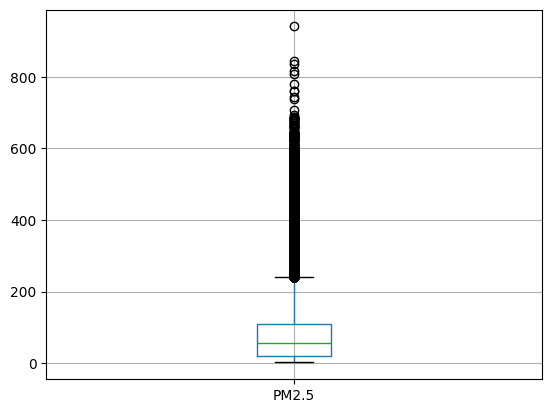

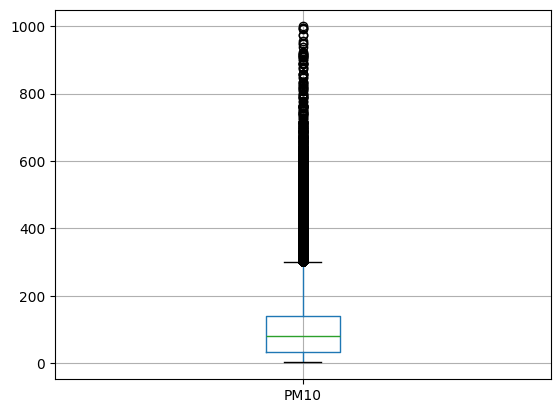

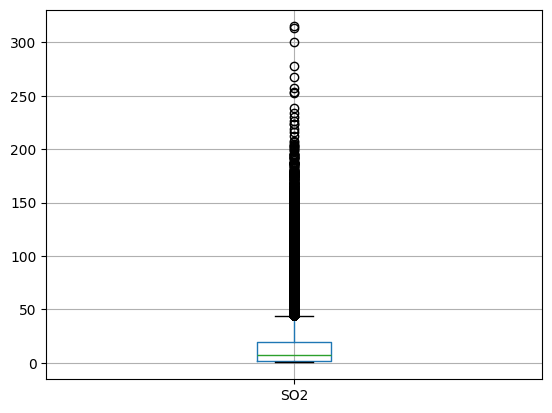

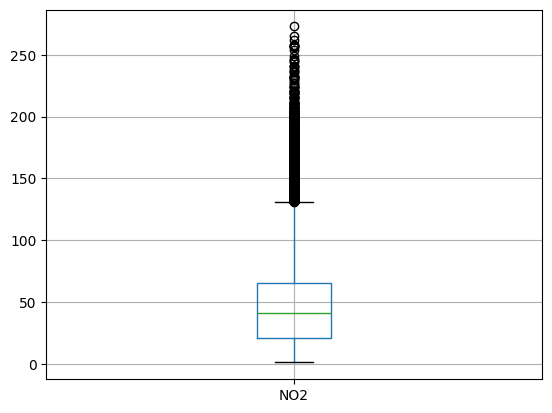

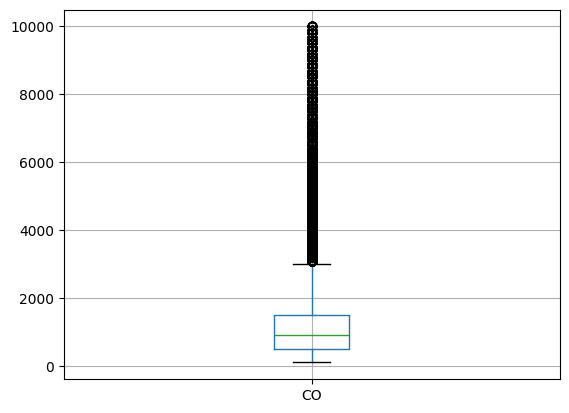

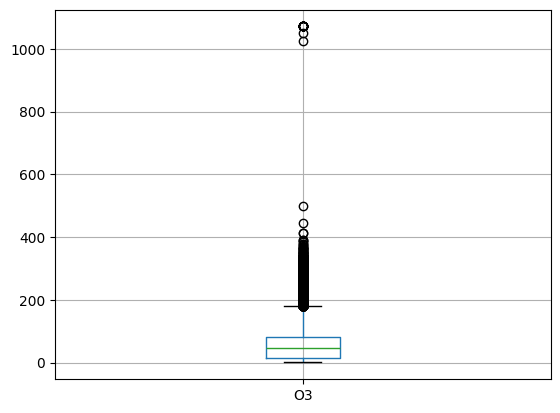

In [265]:
for stat in pollution_components:
    station_data[[stat]].boxplot(showfliers=True)
    plt.show()

Our notebook size has got unmamangable, so we removed the individual region investigation in favour of the combined dataset. You can however use the filtering in the streamlit application to look at individual distributions. Before we visualise however, lets look at the numbers:

In [279]:
tmp = station_data[pollution_components]
for stat in pollution_components:
    print(f'{stat}\tmean: {tmp[stat].mean():.2f}\tmedian: {tmp[stat].median():.2f}\tmode: {tmp[stat].mode().iloc[0]:.2f}\tvariance: {tmp[stat].std()**2:.2f}\tskew: {tmp[stat].skew():.2f}\tkurtosis: {tmp[stat].kurt():.2f}')

PM2.5	mean: 80.06	median: 57.00	mode: 3.00	variance: 6540.84	skew: 2.04	kurtosis: 6.16
PM10	mean: 102.41	median: 81.00	mode: 102.41	variance: 8327.66	skew: 1.94	kurtosis: 6.53
SO2	mean: 15.75	median: 7.00	mode: 2.00	variance: 461.57	skew: 2.94	kurtosis: 12.31
NO2	mean: 47.12	median: 41.00	mode: 47.12	variance: 1089.37	skew: 1.14	kurtosis: 1.56
CO	mean: 1214.82	median: 900.00	mode: 300.00	variance: 1218943.07	skew: 2.69	kurtosis: 10.68
O3	mean: 57.70	median: 47.00	mode: 2.00	variance: 3110.94	skew: 2.08	kurtosis: 14.42


Every one of our pollution measures shows a mean greater than the median greater than the mode. The distributions all have positive skew and kurtosis, some of which are extreme. This confirms our comment about the outliers above.

From these numbers we can ckearly deduce the distributions are *not* Gaussian, exhibit postitive skew with some distrubutions having significant kurtosis, on account of outliers.

In [296]:
def plot_distributions(station: str, data: pd.Series, components=pollution_components):

    fig, ax = plt.subplots(len(components), 1, figsize=(10, 15))

    for i, stat in enumerate(components):
        ax[i].hist(station_data[stat], bins=50)
        ax[i].set(title=f'{station} - {stat}', ylabel='Concentration')

    plt.show()

Some sample graphs demonstrate they are actually Pareto distrbutions, as hinted at by Batterman et al., (2016):

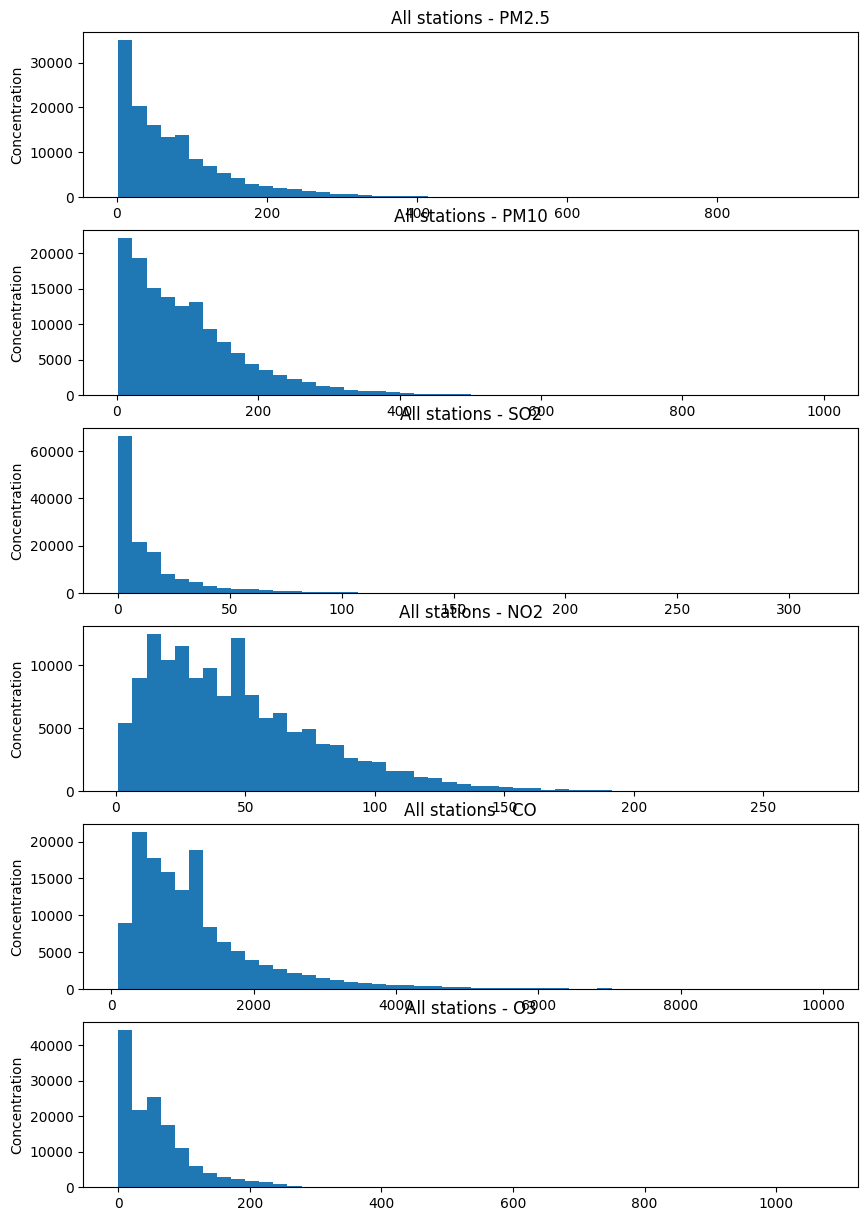

In [297]:
plot_distributions("All stations", tmp)

However compare that with the distributions of the meteorological data. What a wonderful contrast, look at those bimodal distributions for Temperature and Dew Point, while Rainfall is almost Bernoulli, i.e. on or off:

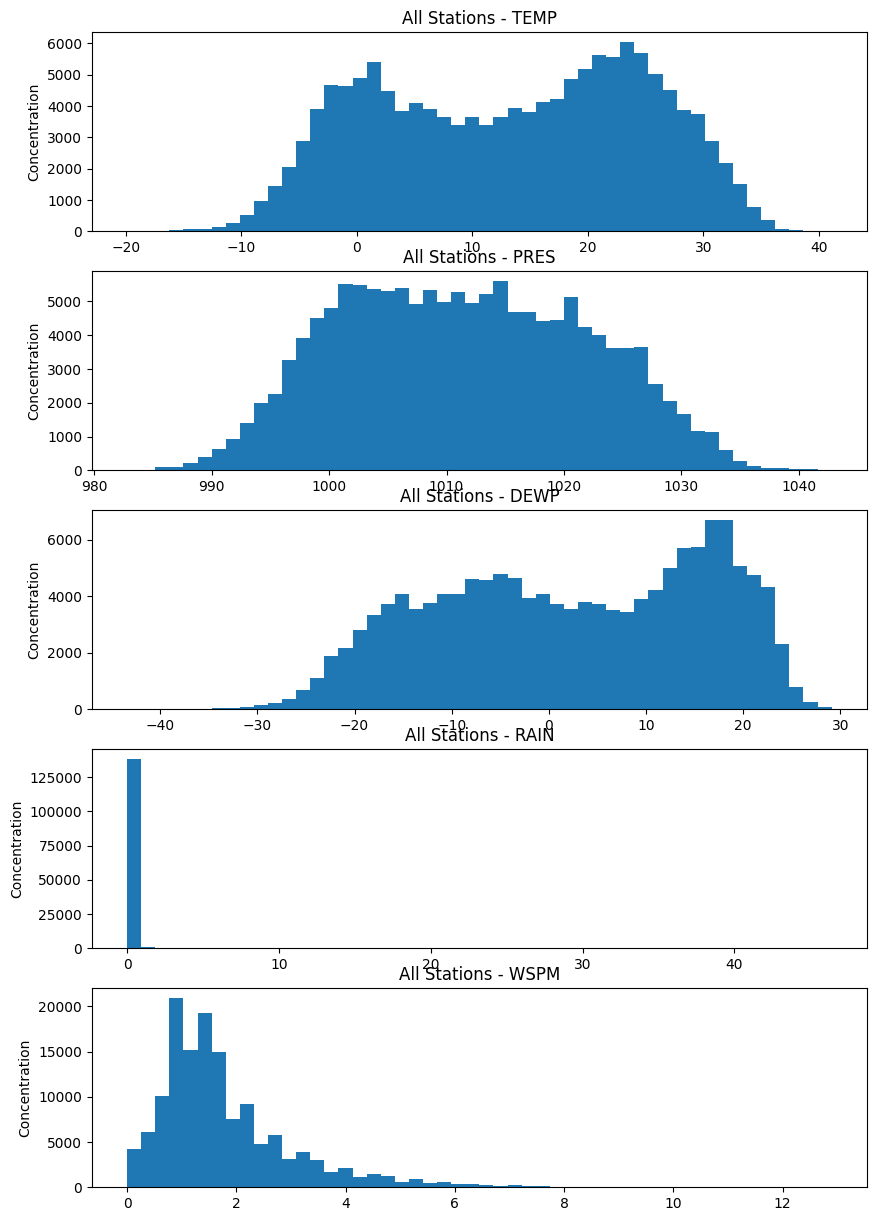

In [299]:
plot_distributions("All Stations", tmp, meteorological_components)

We understand that, perhaps, this was unnecesary for the purposes of the assignment but as the sub-reddit says, _r/dataisbeautiful_ and we wanted to explore it before we started pre-processing.

In [105]:
station_data.to_csv('original_data.csv')

## 2.2. Data Preprocessing
Perform the necessary data preprocessing steps, including but not limited to handling missing values,
removing duplicate entries, feature engineering (e.g., datetime components, AQI levels), and overall data
cleaning on the main dataset.

We already know there is missing data, what is the scale of the problem:

In [106]:
print(f'Dataset length: {len(station_data)}\nMissing entries:')
print(station_data[pollution_components + meteorological_components].isna().sum())

Dataset length: 140256
Missing entries:
PM2.5    3244
PM10     2318
         ... 
RAIN      146
WSPM      121
Length: 11, dtype: int64


We want to visualise that, by station:

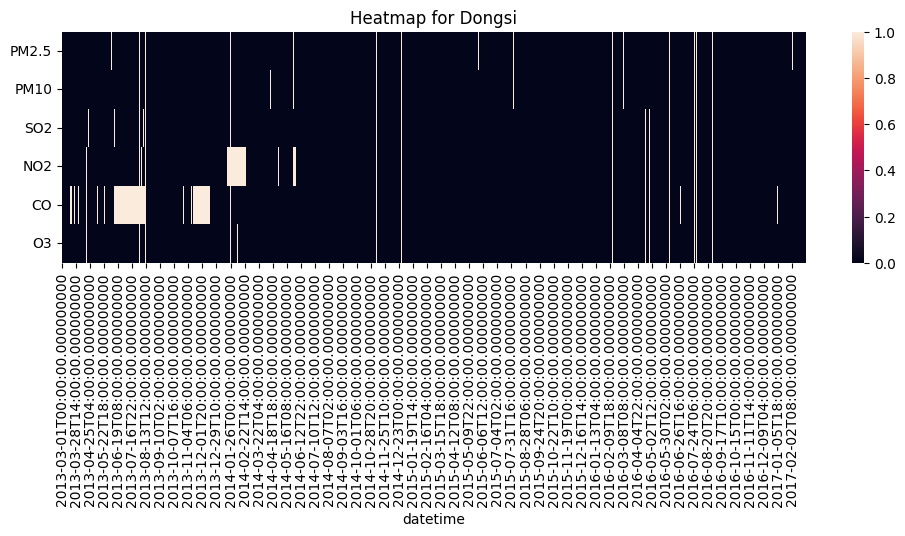

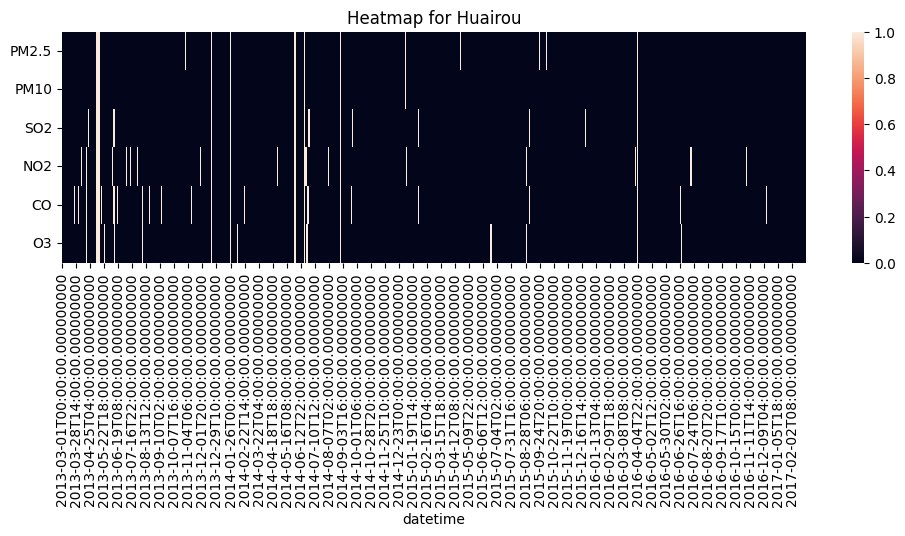

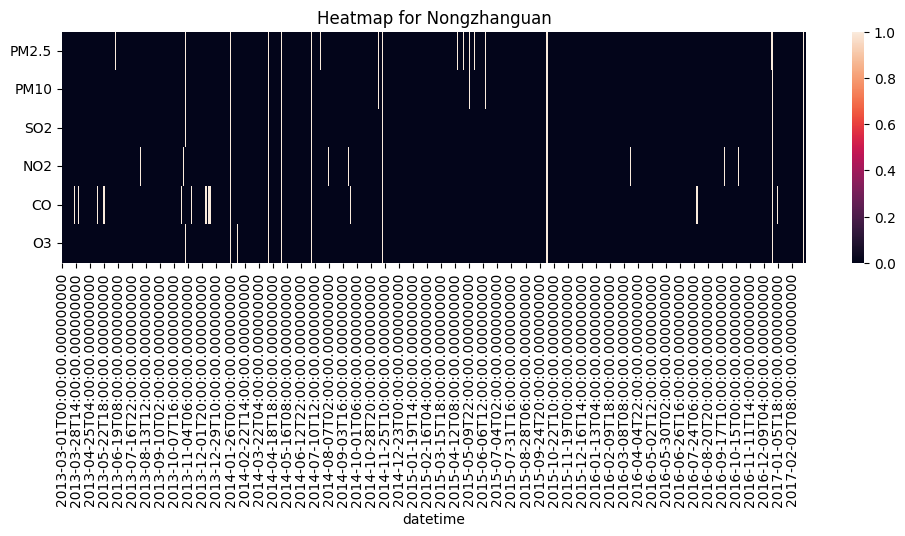

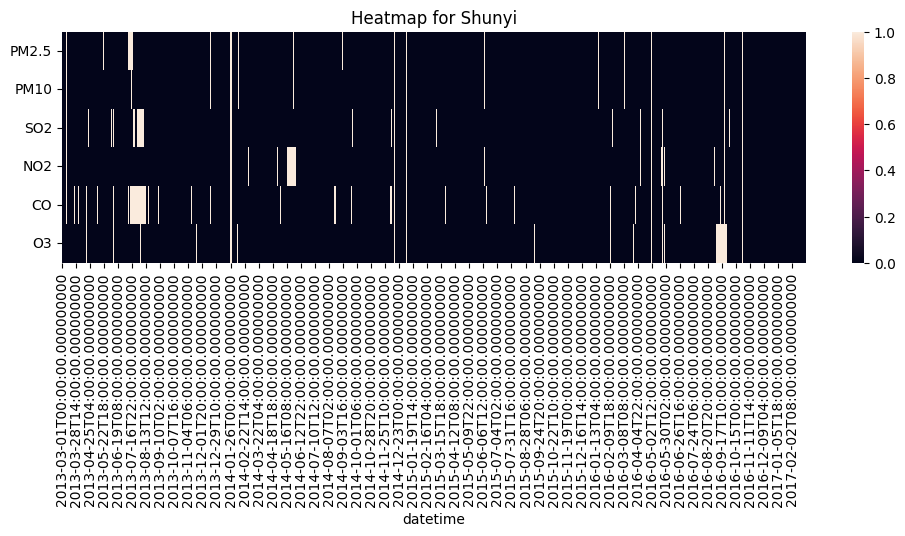

In [107]:
for station, data in tmp:
    plt.figure(figsize=(12, 3))
    sns.heatmap(
        data.isna().T,
    )
    plt.title(f"Heatmap for {station}")
    plt.show()

Some of those gaps look considerable, CO for example. The actual numbers of NAs (from the previous cell) do not visually tally with the heatmaps, which means even the small gaps could be considerable. To prove the point see the gap below:

In [108]:
#pd.set_option('display.max_rows', None)

station_data[station_data['station']=='Dongsi'].loc['2016-09-06':'2016-09-07', 'PM2.5']

datetime
2016-09-06 00:00:00    44.0
2016-09-06 01:00:00    52.0
                       ... 
2016-09-07 22:00:00    24.0
2016-09-07 23:00:00    24.0
Name: PM2.5, Length: 48, dtype: float64

Xu et al., (2020) observed in their study that only 70% of the daily concentration values were valid, citing valid as container 20+ hours of readings. Can we make use of this finding in our analysis:

In [109]:
# TODO: We want to find days that do not contain at least 20 hours of none-NA data
#raise NotImplementedError

That view demonstrates our fears, there are extended periods of NAs not just individual readings which means we have to be smarter than just using a method like linear interpolation.

For now just replace them with the mean values, but this needs to be revisited.
#TODO: Fix this!

In [110]:
station_data[pollution_components] = station_data[pollution_components].fillna(station_data[pollution_components].mean())
station_data[meteorological_components] = station_data[meteorological_components].fillna(station_data[meteorological_components].mean())

Since filling out NA values, a straightforward check for duplicates indicates we do not have any:

In [111]:
print(station_data.duplicated().sum())

0


### Air Quality
Air quality on any particular day is calculated using the PM2.5 measurement (Xu et al., 2020). They record the scale as follows:

| PM2.5 μg/m3 | Air Quality | Indicator |
|-------|-------------|-----------|
| x < 35 | Excellent | <span style="color:rgb(0, 255, 0)">&#9724;</span> |
| 35 <= x < 75 | Favourable | <span style="color:rgb(0, 128, 0)">&#9724;</span> |
| 75 <= x < 115 | Light pollution | <span style="color:rgb(255, 233, 0)">&#9724;</span> |
| 115 <= x < 150 | Moderate pollution | <span style="color:rgb(255, 128, 0)">&#9724;</span> |
| 150 <= x < 250  | Heavy pollution | <span style="color:rgb(255, 0, 0)">&#9724;</span> |
| 250 <= x | Ultra serious pollution | <span style="color:rgb(255, 0, 255)">&#9724;</span> |



Which we translate into a new column in the dataset as follows:

In [112]:
air_q = pd.Categorical(["Excellent", "Favourable", "Light pollution", "Moderate pollution", "Heavy pollution", "Ultra serious pollution"], ordered=True)
air_q_bins = [0, 35, 75, 115, 150, 250, 1000] # Because the PM2.5 max is 941, which should mean 1000 is high enough
station_data['aqi'] = pd.cut(
    station_data['PM2.5'],
    bins=air_q_bins,
    labels=air_q,
    ordered=True,
    right=False # Because that reflects the limits in the table above, which seems to follow Xu's classifications
)

# A quick sanity check seems to look like what I expect to see.
station_data[['PM2.5', "aqi"]].head(50)

,PM2.5,aqi
datetime,,
2013-03-01 00:00:00,3.0,Excellent
2013-03-01 01:00:00,12.0,Excellent
...,...,...
2013-03-03 00:00:00,125.0,Moderate pollution
2013-03-03 01:00:00,96.0,Light pollution


We need to consider outliers:

In [113]:
#raise NotImplementedError

The literature review suggests seassonal, diurnal, and weekday patterns are visible in the PM2.5 data, plus Government edicts affecting car usage are visible (Yao et al. 2015). Lets include day of the week so we can insepct these:

In [114]:
station_data['weekday'] = station_data.index.dayofweek
station_data.head()

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,aqi,weekday
datetime,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,3.0,6.0,3.000000,8.000000,300.000000,44.000000,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi,Excellent,4
2013-03-01 01:00:00,2,12.0,12.0,3.000000,7.000000,300.000000,47.000000,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi,Excellent,4
2013-03-01 02:00:00,3,14.0,14.0,15.751506,7.000000,200.000000,22.000000,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi,Excellent,4
2013-03-01 03:00:00,4,12.0,12.0,3.000000,5.000000,1214.821048,57.701269,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi,Excellent,4
2013-03-01 04:00:00,5,12.0,12.0,3.000000,47.123689,200.000000,11.000000,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi,Excellent,4


Holidays affect people's behaviour too, so lets capture that:

In [115]:
hols = holidays.country_holidays('CN')
station_data['holiday'] = station_data.index.to_series().apply(lambda hol: hol in hols)
station_data[station_data['holiday']==True].count()

No         8160
PM2.5      8160
           ... 
weekday    8160
holiday    8160
Length: 17, dtype: int64

Furthermore, the literature also concludes that pollution is worse during the winter/heating season, further seasonality may be captured by including week numbers - %W indicating Monday should be considered the first day of the week:

In [116]:
station_data['week_no'] = station_data.index.strftime('%W')
station_data

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,aqi,weekday,holiday,week_no
datetime,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi,Excellent,4,False,08
2013-03-01 01:00:00,2,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi,Excellent,4,False,08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-28 22:00:00,35063,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou,Excellent,1,False,09
2017-02-28 23:00:00,35064,11.0,20.0,2.0,27.0,400.0,77.0,6.7,1009.3,-13.6,0.0,NE,1.9,Huairou,Excellent,1,False,09


Now is a good point to add one-hot encoding:

In [117]:
pd.set_option('display.max_columns', None)

station_data = pd.get_dummies(station_data)
station_data.head()

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,weekday,holiday,wd_E,wd_ENE,wd_ESE,wd_N,wd_NE,wd_NNE,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW,station_Dongsi,station_Huairou,station_Nongzhanguan,station_Shunyi,aqi_Excellent,aqi_Favourable,aqi_Heavy pollution,aqi_Light pollution,aqi_Moderate pollution,aqi_Ultra serious pollution,week_no_00,week_no_01,week_no_02,week_no_03,week_no_04,week_no_05,week_no_06,week_no_07,week_no_08,week_no_09,week_no_10,week_no_11,week_no_12,week_no_13,week_no_14,week_no_15,week_no_16,week_no_17,week_no_18,week_no_19,week_no_20,week_no_21,week_no_22,week_no_23,week_no_24,week_no_25,week_no_26,week_no_27,week_no_28,week_no_29,week_no_30,week_no_31,week_no_32,week_no_33,week_no_34,week_no_35,week_no_36,week_no_37,week_no_38,week_no_39,week_no_40,week_no_41,week_no_42,week_no_43,week_no_44,week_no_45,week_no_46,week_no_47,week_no_48,week_no_49,week_no_50,week_no_51,week_no_52
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,3.0,6.0,3.000000,8.000000,300.000000,44.000000,-0.9,1025.8,-20.5,0.0,9.3,4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2013-03-01 01:00:00,2,12.0,12.0,3.000000,7.000000,300.000000,47.000000,-1.1,1026.1,-21.3,0.0,9.4,4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2013-03-01 02:00:00,3,14.0,14.0,15.751506,7.000000,200.000000,22.000000,-1.7,1026.2,-23.0,0.0,8.6,4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2013-03-01 03:00:00,4,12.0,12.0,3.000000,5.000000,1214.821048,57.701269,-2.1,1027.3,-23.3,0.0,6.6,4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2013-03-01 04:00:00,5,12.0,12.0,3.000000,47.123689,200.000000,11.000000,-2.4,1027.7,-22.9,0.0,4.5,4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [118]:
pd.set_option('display.max_rows', 5)

## 2.3. Statistical/Computational Analysis & Visualisation
Perform the necessary steps such as univariate (distribution of pollutants & meteorological variables),
bivariate(e.g. relationships such as PM2.5 vs. Temp, NO2 vs. O3 but not limited to these), and
multivariate analysis (correlation, heatmaps, pairplots), statistical summary, and visualizing the data
(Various charts and graphs, such as bar charts, line charts and scatter plots) that will help in
understanding relationships between variables and to gain important insights from data. Interpret the
key results to demonstrate understanding generated from statistical and visual analysis.
• Explore the dataset however you find meaningful. You may examine different variables, compare
stations, investigate temporal behaviours, or analyse interactions between pollutants and
meteorological factors. Choose the approaches that you believe best help you understand and interpret
the dataset, and present the insights you consider most relevant

Previously we looked at the individual distributions, now lets start proper and see what the combined data looks like, we assume the combinations will be similar:

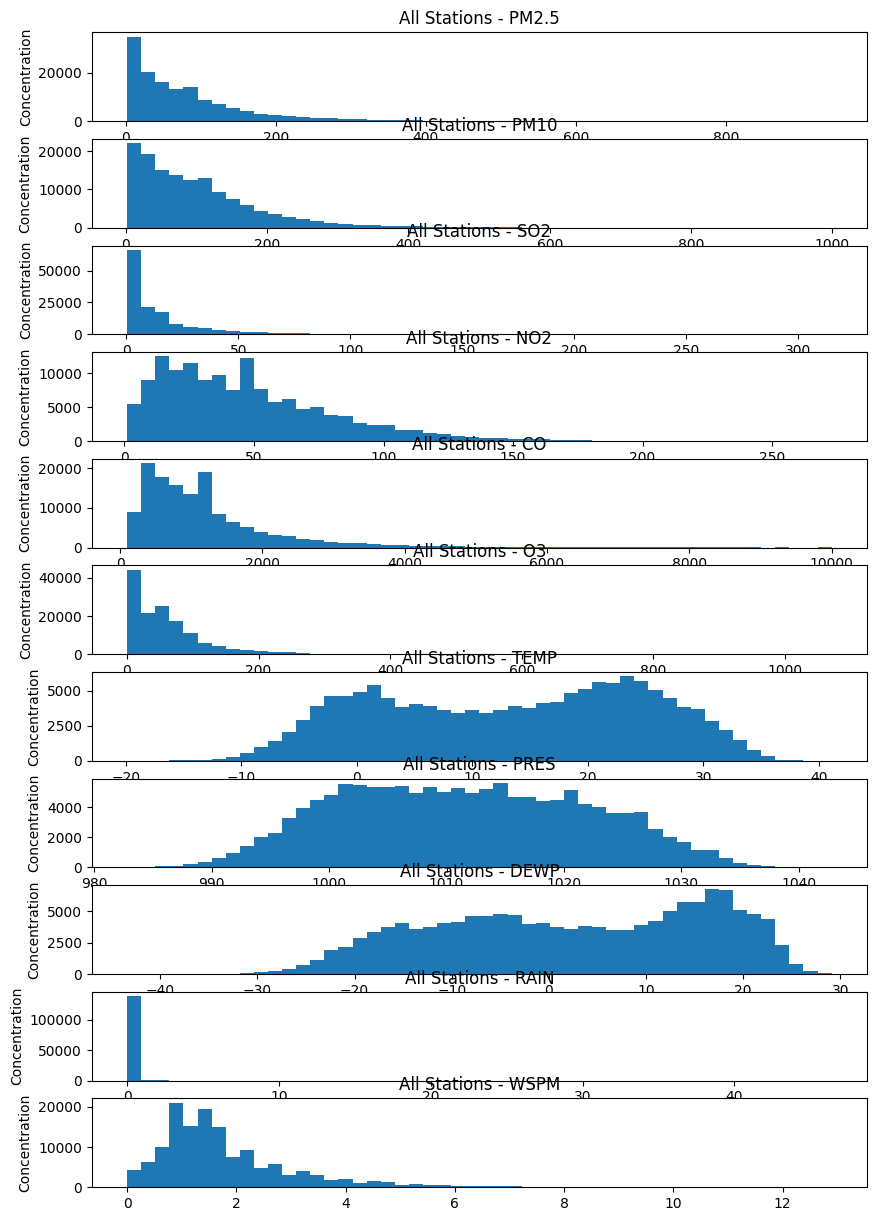

In [119]:
plot_distributions('All Stations', station_data, pollution_components + meteorological_components)

In [120]:
from statsmodels.tsa.stattools import adfuller

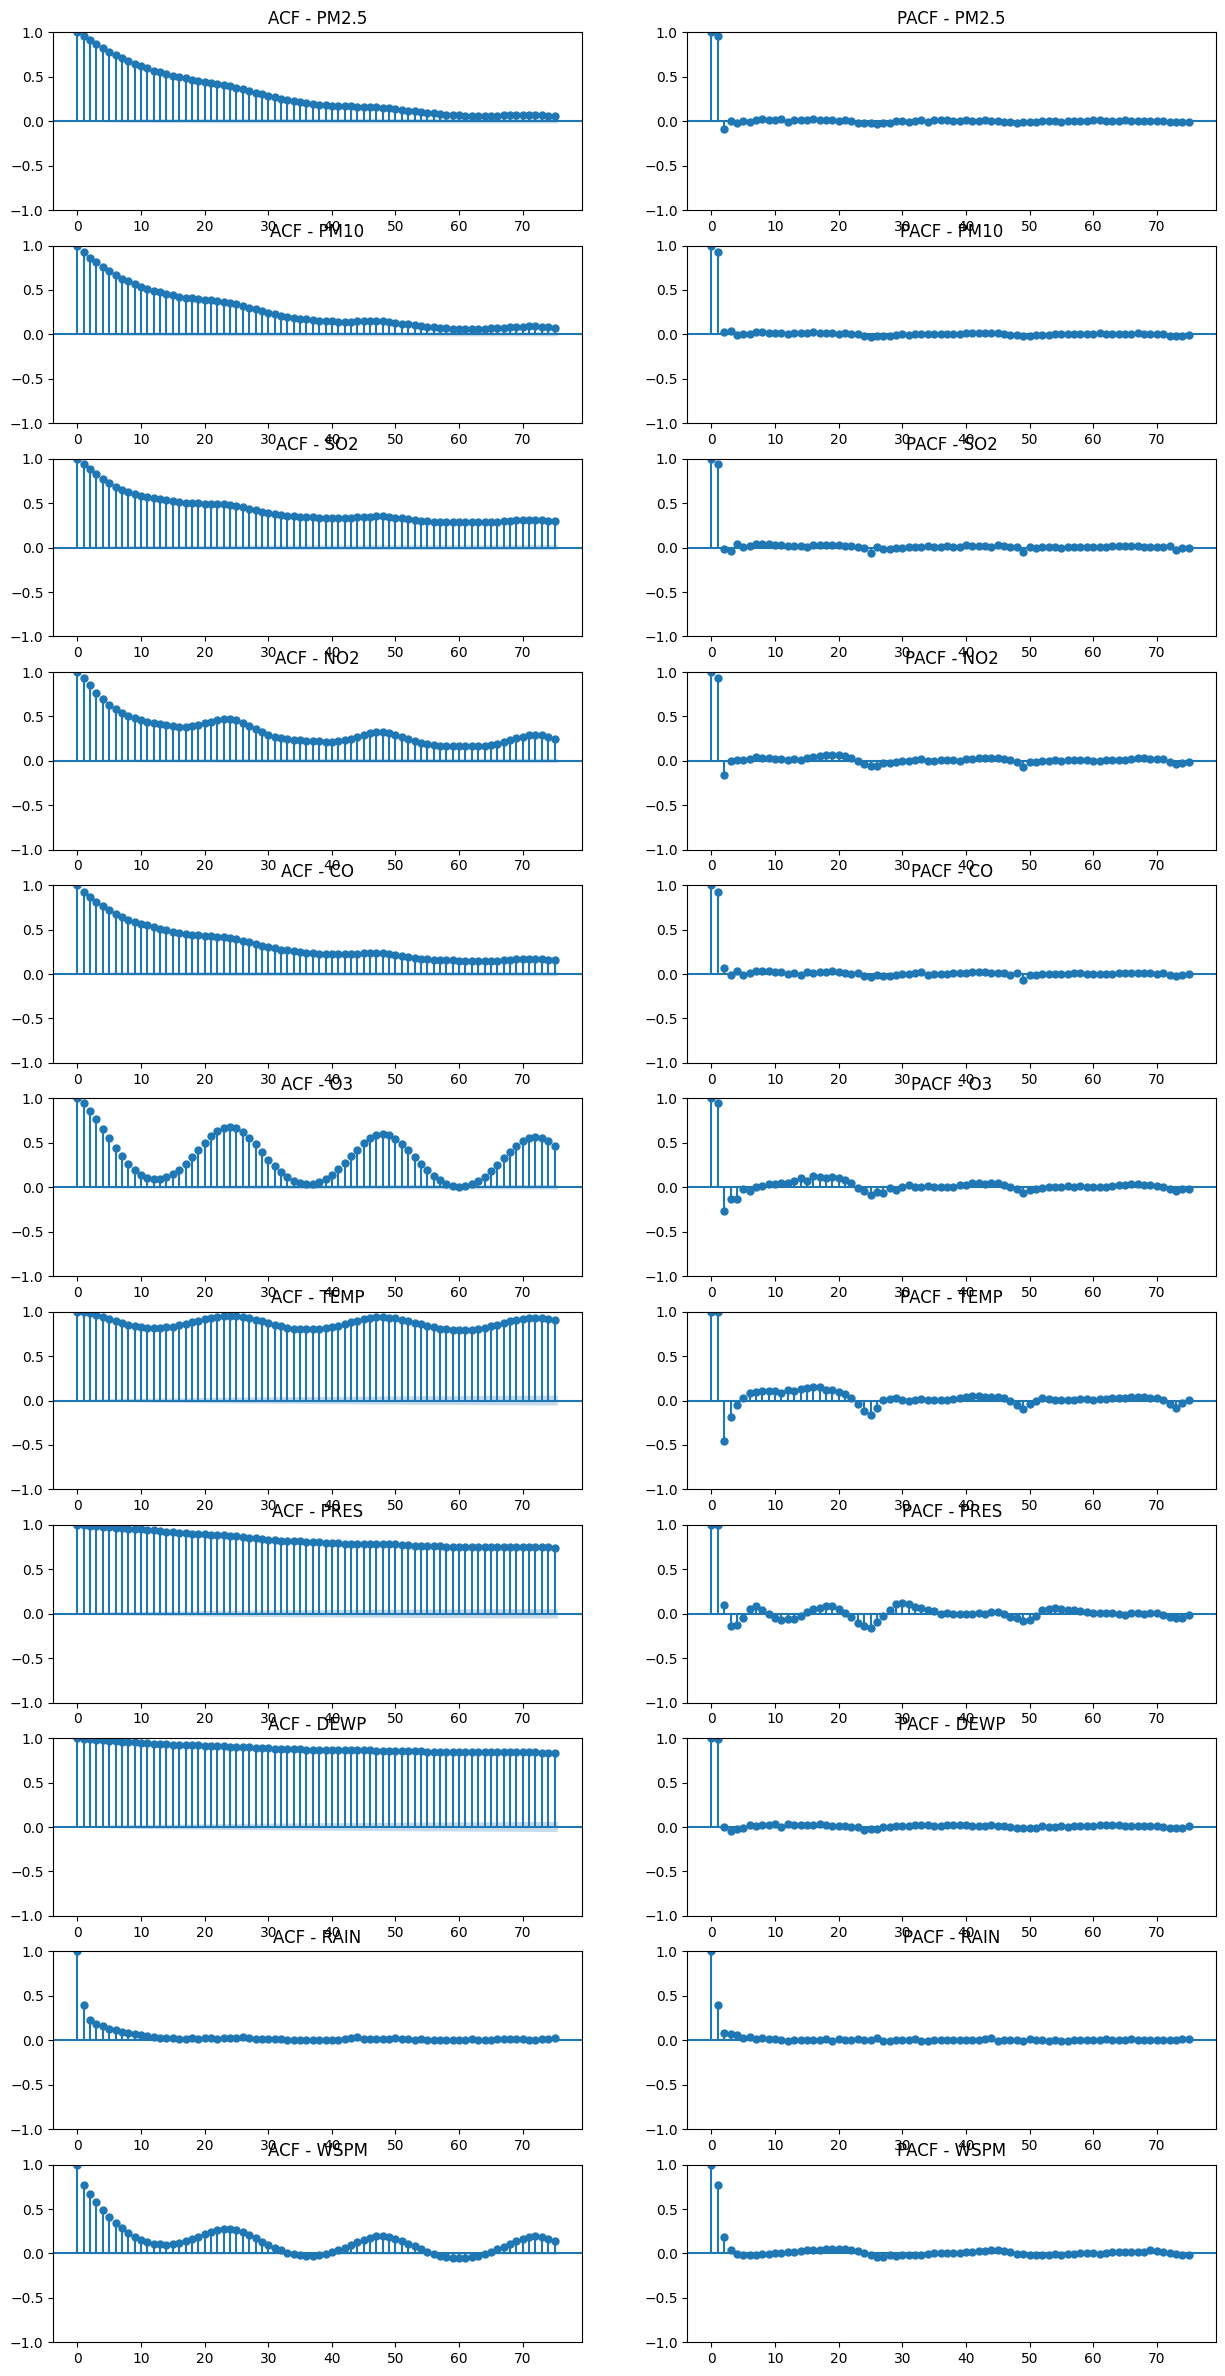

In [121]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

components = pollution_components + meteorological_components
fig, ax = plt.subplots(len(components), 2, figsize=(15,30))

for i, stat in enumerate(pollution_components + meteorological_components):
    plot_acf(station_data[stat], lags=75, title=f'ACF - {stat}', ax=ax[i, 0])
    plot_pacf(station_data[stat], lags=75, title=f'PACF - {stat}', ax=ax[i, 1])
plt.show()

What beautiful graphs, unsurprisingly hourly decaying correlations exist in most of the pollution components, as demonstrated in the ACFs.

Look at that beautiful 24-hour oscillating pattern in the ozone numbers (O3). We think there is no need to explicitly explain the correlations with Temperature, Pressure, and Dew Point.

In [122]:
#from scipy.stats import ks_2samp

#d = station_data[station_data['station']=='Dongsi']
#h = station_data[station_data['station']=='Huairou']
#n = station_data[station_data['station']=='Nongzhanguan']
#s = station_data[station_data['station']=='Shunyi']
#ks_2samp(d['PM2.5'].dropna(), h['PM2.5'].dropna())
#ks_2samp(d['PM2.5'].dropna(), n['PM2.5'].dropna())
#ks_2samp(h['PM2.5'].dropna(), s['PM2.5'].dropna())
#ks_2samp(d['PM2.5'].dropna(), d['PM10'].dropna())

In [123]:
# station_cats = pd.get_dummies(station_data['station'])
# station_data = pd.concat([station_data, station_cats], axis=1)
# station_data = station_data.drop('station', axis=1)

In a real-world web app, the front end would be just that, a thin client that asked the back end for data - to which the front end would then apply fiters. We have attempted to seperate concerns here by using a flat file to represent responses from the business logic: 

In [124]:
station_data.to_csv('processed.csv')

# Task 3: Model Building
After completing all the tasks listed under Task 1 and Task 2, identify and implement the best practices
to build a suitable machine-learning model (e.g., feature scaling, encoding techniques, variable selection,
and parameter optimization).
• Justify your modelling decisions and evaluate model performance using appropriate metrics.

# Task 4: Application Development
Develop an interactive application with a graphical user interface (GUI). The application should include multiple
sections/pages that allow users to explore
• The dataset section,
• Visualization section, and
• Model outputs section.
You may design the structure in any way you find appropriate, but it should enable clear navigation between the
key components of your workflow.

In [125]:
station_data

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,weekday,holiday,wd_E,wd_ENE,wd_ESE,wd_N,wd_NE,wd_NNE,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW,station_Dongsi,station_Huairou,station_Nongzhanguan,station_Shunyi,aqi_Excellent,aqi_Favourable,aqi_Heavy pollution,aqi_Light pollution,aqi_Moderate pollution,aqi_Ultra serious pollution,week_no_00,week_no_01,week_no_02,week_no_03,week_no_04,week_no_05,week_no_06,week_no_07,week_no_08,week_no_09,week_no_10,week_no_11,week_no_12,week_no_13,week_no_14,week_no_15,week_no_16,week_no_17,week_no_18,week_no_19,week_no_20,week_no_21,week_no_22,week_no_23,week_no_24,week_no_25,week_no_26,week_no_27,week_no_28,week_no_29,week_no_30,week_no_31,week_no_32,week_no_33,week_no_34,week_no_35,week_no_36,week_no_37,week_no_38,week_no_39,week_no_40,week_no_41,week_no_42,week_no_43,week_no_44,week_no_45,week_no_46,week_no_47,week_no_48,week_no_49,week_no_50,week_no_51,week_no_52
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,9.3,4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2013-03-01 01:00:00,2,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,9.4,4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-28 22:00:00,35063,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,3.2,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2017-02-28 23:00:00,35064,11.0,20.0,2.0,27.0,400.0,77.0,6.7,1009.3,-13.6,0.0,1.9,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
%%writefile backend_stub.py

import pandas as pd
import io
from enum import Enum, auto
from http import HTTPStatus

original = pd.read_csv('original_data.csv')
processed = pd.read_csv('processed.csv')

def get_data(regions=None, date_from=None, date_to=None, components=None):

    if (regions is None or len(regions)==0) and components is None:
        return original

    result = []
    tmp = original.groupby('station')
    #tmp = processed.groupby('station')
    
    for region in regions:
        result.append(tmp.get_group(region))
    result = pd.concat(result)

    if date_from is not None:
        result = result[pd.to_datetime(result['datetime']) >= pd.to_datetime(date_from)]

    if date_to is not None:
        result = result[pd.to_datetime(result['datetime']) <= pd.to_datetime(date_to)]
    
    if components is not None:
        result = result[['No', 'station', components]]

    return result

def get_region_names(regions=None, date_from=None, date_to=None):
    return original['station'].unique()

def get_component_names(regions=None, date_from=None, date_to=None):
    return original.columns

def get_dataset_shape(regions=None, date_from=None, date_to=None):
    return get_data(regions, date_from, date_to).shape

def get_dataset_info(regions=None, date_from=None, date_to=None):
    df = get_data(regions, date_from, date_to)
    result = io.StringIO()
    df.info(buf=result)
    return result.getvalue()

def get_dataset_description(regions=None, date_from=None, date_to=None):
    return get_data(regions, date_from, date_to).describe()

def get_dataset_nans(regions=None, date_from=None, date_to=None):

    data = get_data(regions, date_from, date_to)
    nans = data.isna().sum()
    row_total = len(data)
    nan_tab = pd.concat([nans, (nans/row_total)*100], axis=1)
    nan_tab.rename(columns={0: 'Missing Values', 1: '% of Total Values'}, inplace=True)
    nan_tab.sort_values('% of Total Values', ascending=False, inplace=True)
    return nan_tab.style.background_gradient(cmap='Greens')

import matplotlib.pyplot as plt

def get_histogram(regions=None, date_from=None, date_to=None, components='PM2.5'):

    df = get_data(regions, date_from, date_to, components)

    fig = plt.figure()
    plt.hist(df[components], bins=50)
    plt.xlabel("")
    plt.xticks([])

    return fig

def get_boxplot(regions=None, date_from=None, date_to=None, components='PM2.5'):

    df = get_data(regions, date_from, date_to, components)

    fig = plt.figure()
    ax = df[[components]].boxplot()
    ax.set_xlabel("")
    ax.set_xticklabels([])

    return fig

class Endpoint(Enum):
    DATA = auto()
    REGIONS = auto()
    COLUMNS = auto()
    SHAPE = auto()
    INFO = auto()
    DESC = auto()
    NANS = auto()
    HIST = auto()
    BOX = auto()

ENDPOINTS = {
    Endpoint.DATA : get_data,
    Endpoint.REGIONS : get_region_names,
    Endpoint.COLUMNS : get_component_names,
    Endpoint.SHAPE : get_dataset_shape,
    Endpoint.INFO : get_dataset_info,
    Endpoint.DESC : get_dataset_description,
    Endpoint.NANS : get_dataset_nans,
    Endpoint.HIST : get_histogram,
    Endpoint.BOX : get_boxplot,
}

class DatasetAPI:

    @staticmethod
    def request(endpoint, regions=None, date_from=None, date_to=None, components=None):

        if not isinstance(endpoint, Endpoint):
            return {'status': HTTPStatus.BAD_REQUEST, 'data': 'Endpoint does not exist'}
        
        if endpoint not in ENDPOINTS:
            return {'status': HTTPStatus.INTERNAL_SERVER_ERROR, 'data': ''}

        # TODO: Temporary fudge
        if endpoint in [Endpoint.HIST, Endpoint.BOX]:
            return {'status': HTTPStatus.OK, 'data': ENDPOINTS[endpoint](regions, date_from, date_to, components)}
            
        return {'status': HTTPStatus.OK, 'data': ENDPOINTS[endpoint](regions, date_from, date_to)}

Overwriting backend_stub.py


In [ ]:
#type(get_component_names())

pandas.core.indexes.base.Index

In [207]:
%%writefile components/nav.py

import streamlit as st
from streamlit_option_menu import option_menu

OPTIONS = [
"Home",
"Dataset Information",
"Initial Observations"
"Data Preprocessing",
"Statistical Analysis",
"Modeling",
]

ROUTES = {
"Home": "app.py",
"Dataset Information": "pages/dataset_information.py",
"Initial Observations": "pages/initial_observations.py",
"Data Preprocessing": "pages/data_preprocessing.py",
"Statistical Analysis": "pages/statistical_analysis.py",
"Modeling": "pages/model.py",
}

def switch_page(selected: str) -> None:

    if 'current_page' not in st.session_state:
        st.session_state.current_page = selected

    if selected != st.session_state.current_page:

        st.session_state.current_page = selected

        st.switch_page(ROUTES[selected])


def render_navbar() -> str:

    selected = 0
    if 'current_page' in st.session_state:
        selected = OPTIONS.index(st.session_state.current_page)

    with st.sidebar:
        selected = option_menu(
            menu_title='Navigation',
            options=['Home', 'Dataset Information', 'Initial Observations', 'Data Preprocessing', 'Statistical Analysis', 'Modeling'],
            icons=['house', 'list-task', 'graph-up', 'gear', 'graph-up', 'gear'],
            menu_icon="cast",
            #default_index=0,
            manual_select=selected
        )

    switch_page(selected)

    return selected

Overwriting components/nav.py


In [177]:
%%writefile components/filter.py

import datetime
import streamlit as st
import backend_stub as bs

# TODO: This file needs to use the Faux-RESTful API before submission

def dataset_filter():

    with st.expander('Dataset Filter'):
        all_regions = bs.get_region_names()
        regions = st.multiselect('Region', all_regions)
        select_all = st.checkbox('Select all', value=[len(regions)==0])
        if select_all:
            regions = all_regions

        min_date = datetime.date(2013, 3, 1)
        max_date = datetime.date(2017, 2, 28)
        date_from = st.date_input("From date",
                        value=min_date,
                        min_value=min_date,
                        max_value=max_date,
                        format="YYYY.MM.DD",
        )
        date_to = st.date_input("From date",
                        value=max_date,
                        min_value=date_from,
                        max_value=max_date,
                        format="YYYY.MM.DD",
        )

    return regions, date_from, date_to

def component_filter(multivariate=False):

    #data = request_data(ep.COLUMNS, regions, date_from, date_to)
    components = bs.get_component_names()
    components = components.drop(['datetime', 'No', 'station'])

    with st.expander('Component Filter'):
        
        if multivariate:
            return st.multiselect('Components', components)
        
        return st.selectbox('Component', components)

Overwriting components/filter.py


In [205]:
%%writefile pages/dataset_information.py

import streamlit as st
from http import HTTPStatus
from backend_stub import DatasetAPI as api, Endpoint as ep
from components import nav
from components import filter as fc

def request_data(endpoint, regions, date_from, date_to):

    response = api.request(endpoint, regions, date_from, date_to)
    
    if response['status'] == HTTPStatus.OK:
        return response['data']

    raise Exception(f'An error occurred {response['status']}')  

st.set_page_config(layout='wide')

selected = nav.render_navbar()
st.title(selected)

regions, date_from, date_to = fc.dataset_filter()

st.markdown('## Dataset Description')
st.dataframe(request_data(ep.DESC, regions, date_from, date_to))

col1, col2 = st.columns(2)

with col1:
    st.markdown("## Dataset Shape")
    data = request_data(ep.SHAPE, regions, date_from, date_to)
    st.write(f'Rows: {data[0]}')
    st.write(f'Columns: {data[1]}')

    st.markdown("## Dataset NANs")
    data = request_data(ep.NANS, regions, date_from, date_to)
    st.write(data)

with col2:
    st.markdown('## Column Info')
    data = request_data(ep.COLUMNS, regions, date_from, date_to)
    st.write(data)

st.markdown('## Dataset Info')
data = request_data(ep.INFO, regions, date_from, date_to)
st.text(data)

Writing pages/dataset_information.py


In [256]:
%%writefile pages/initial_observations.py

import streamlit as st
from http import HTTPStatus
from backend_stub import DatasetAPI as api, Endpoint as ep
from components import nav
from components import filter as fc

# TODO: This needs to find one place to live
def request_data(endpoint, regions, date_from, date_to, component):

    response = api.request(endpoint, regions, date_from, date_to, component)
    
    if response['status'] == HTTPStatus.OK:
        return response['data']

    raise Exception(f'An error occurred {response['status']}')  

st.set_page_config(layout='wide')

selected = nav.render_navbar()
st.title(selected)

col1, col2 = st.columns(2)
with col1:
    regions, date_from, date_to = fc.dataset_filter()

with col2:
    pollution_component = fc.component_filter(False)

st.markdown("---")

active_filter = f'##### Data for  {', '.join(regions)} between {date_from} to {date_to}'
st.markdown(active_filter)
st.markdown("---")

left, right = st.columns(2, gap="small")
with left:
    data = request_data(ep.HIST, regions, date_from, date_to, pollution_component)

    with st.container(height=500):
        
        st.markdown(f'##### Distribution of {pollution_component} concentrations')
        st.pyplot(data)

    st.markdown("---")

with right:

    data = request_data(ep.BOX, regions, date_from, date_to, pollution_component)

    with st.container(height=500):

        st.markdown(f'##### Boxplot of {pollution_component} concentrations')
        st.pyplot(data)

    st.markdown("---")


Overwriting pages/initial_observations.py


In [200]:
%%writefile pages/data_preprocessing.py

import streamlit as st
import backend_stub as bs
from components import nav
from components import filter as fc

selected = nav.render_navbar()
st.title(selected)
regions, date_from, date_to = fc.dataset_filter()

Overwriting pages/data_preprocessing.py


In [201]:
%%writefile pages/statistical_analysis.py

import streamlit as st
from http import HTTPStatus
from backend_stub import DatasetAPI as api, Endpoint as ep
from components import nav
from components import filter as fc

st.set_page_config(layout='wide')

selected = nav.render_navbar()
st.title(selected)

Overwriting pages/statistical_analysis.py


In [202]:
%%writefile pages/model.py

import streamlit as st
import backend_stub as bs
from components import nav
from components import filter as fc

selected = nav.render_navbar()
st.title(selected)

regions, date_from, date_to = fc.dataset_filter()

Overwriting pages/model.py


In [203]:
%%writefile app.py

import streamlit as st
from http import HTTPStatus
from backend_stub import DatasetAPI as api, Endpoint as ep
from components import nav
from components import filter as fc

# TODO: This needs to find one place to live
def request_data(endpoint, regions, date_from, date_to, component):

    response = api.request(endpoint, regions, date_from, date_to, component)
    
    if response['status'] == HTTPStatus.OK:
        return response['data']

    raise Exception(f'An error occurred {response['status']}')  

st.set_page_config(layout='wide')

selected = nav.render_navbar()
st.title(selected)

regions, date_from, date_to = fc.dataset_filter()
data = request_data(ep.DATA, regions, date_from, date_to, None)
st.dataframe(data)

Overwriting app.py


In [135]:
import datetime
datetime.date(2013, 3, 1)
pd.to_datetime(datetime.date(2013, 3, 1))

Timestamp('2013-03-01 00:00:00')

In [136]:
#!pip install node

In [137]:
if 'google.colab' in sys.modules:
    !streamlit run app.py & npx localtunnel --port 8501

# Task 5: Version Control
Use GitHub for version control.
• Commit changes regularly with clear, descriptive messages, for example, added PM2.5 prediction
model”, “Created correlation heatmap,” etc.
• Maintain an organised repository structure and include screenshots of:
▫ GitHub commit history
▫ GitHub project repository layout

# References
Batterman, S. et al. (2016) 'Characteristics of PM2.5 concentrations across Beijing during 2013–2015', _Atmospheric Environment_, 145, 104–114. Available at: https://doi.org/10.1016/j.atmosenv.2016.08.060

McKinney, W. (2022) _Python for Data Analysis, 3rd Edition_. O'Reilly Media, Inc. Available at: https://learning.oreilly.com/library/view/python-for-data/9781098104023/

Yao, L. et al. (2015) 'Comparison of hourly PM2.5 observations between urban and suburban areas in Beijing, China', _International Journal of Environmental Research and Public Health_, 12(10), 12264–12276. Available at: https://doi.org/10.3390/ijerph121012264

Xu, X., Zhang, T. (2020) 'Spatial-temporal variability of PM2.5 air quality in Beijing, China during 2013–2018', _Journal of Environmental Management_, 262. Available at: https://doi.org/10.1016/j.jenvman.2020.110263

# AI Statement